In [ ]:
!pip install torch_geometric ogb

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv

class VanillaGIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            layer_in = in_channels if i == 0 else hidden_channels
            layer_out = hidden_channels 

            mlp = nn.Sequential(
                nn.Linear(layer_in, hidden_channels),
                nn.BatchNorm1d(hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, layer_out)
            )
            
            self.convs.append(GINConv(mlp, train_eps=True))
            
            if i < num_layers - 1:
                self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.post_lp = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        x = self.post_lp(x)
        return x

In [2]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected, AddSelfLoops, Compose
import time

if not hasattr(torch.load, '_patched'):
    _original_load = torch.load

    def _patched_load(f, **kwargs):
        kwargs["weights_only"] = False
        return _original_load(f, **kwargs)

    _patched_load._patched = True
    torch.load = _patched_load

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    transform=Compose([ToUndirected(), AddSelfLoops()])
)

split_idx = dataset.get_idx_split()
data = dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_idx = split_idx['train'].to(device)
val_idx   = split_idx['valid'].to(device)
test_idx  = split_idx['test'].to(device)

print(data)
print(f"Device: {device}")
print(f"Num classes: {dataset.num_classes}")

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:03<00:00, 22.42it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 11335.96it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 396.17it/s]

Saving...



Done!


Data(num_nodes=169343, edge_index=[2, 2484941], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Device: cuda
Num classes: 40


In [4]:
evaluator = Evaluator(name='ogbn-arxiv')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx].squeeze())

    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    results = {}
    for split, idx in [('train', train_idx), ('valid', val_idx), ('test', test_idx)]:
        acc = evaluator.eval({
            'y_true': data.y[idx],
            'y_pred': pred[idx]
        })['acc']
        results[split] = acc
    return results

In [5]:
model = VanillaGIN(
    in_channels=dataset.num_features,
    hidden_channels=256,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',
    factor=0.5,
    patience=20,
)
print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

VanillaGIN(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (post_lp): Linear(in_features=256, out_features=40, bias=True)
)
Num parameters: 374,827


In [6]:
NUM_EPOCHS = 500
patience = 50
counter = 0

best_val_acc = 0
best_test_acc = 0

history = {
    'epoch': [],
    'loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t

    if epoch % 10 == 0:
        results = evaluate(model)

        val_acc = results['valid']
        scheduler.step(val_acc)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train: {results['train']:.4f} | "
              f"Val: {results['valid']:.4f} | "
              f"Test: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['train_acc'].append(results['train'])
        history['val_acc'].append(results['valid'])
        history['test_acc'].append(results['test'])

        # early stopping logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = results['test']
            counter = 0
            torch.save(model.state_dict(), 'best_gin_vanilla_node.pt')
        else:
            counter += 10

        if counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch 010 | Loss: 2.8997 | Train: 0.2136 | Val: 0.1716 | Test: 0.1562 | Time: 0.37s
Epoch 020 | Loss: 2.7967 | Train: 0.2478 | Val: 0.2666 | Test: 0.2699 | Time: 0.38s
Epoch 030 | Loss: 2.6740 | Train: 0.2640 | Val: 0.3058 | Test: 0.3027 | Time: 0.38s
Epoch 040 | Loss: 2.6058 | Train: 0.2940 | Val: 0.3321 | Test: 0.3249 | Time: 0.38s
Epoch 050 | Loss: 2.4971 | Train: 0.3053 | Val: 0.3715 | Test: 0.3621 | Time: 0.38s
Epoch 060 | Loss: 2.4263 | Train: 0.3493 | Val: 0.4043 | Test: 0.3872 | Time: 0.38s
Epoch 070 | Loss: 2.2843 | Train: 0.3659 | Val: 0.4203 | Test: 0.4046 | Time: 0.38s
Epoch 080 | Loss: 2.3050 | Train: 0.3584 | Val: 0.4030 | Test: 0.4023 | Time: 0.39s
Epoch 090 | Loss: 2.1505 | Train: 0.3979 | Val: 0.4419 | Test: 0.4592 | Time: 0.39s
Epoch 100 | Loss: 2.2158 | Train: 0.3449 | Val: 0.3728 | Test: 0.4010 | Time: 0.39s
Epoch 110 | Loss: 2.0772 | Train: 0.4143 | Val: 0.4676 | Test: 0.4708 | Time: 0.39s
Epoch 120 | Loss: 2.1927 | Train: 0.4261 | Val: 0.4625 | Test: 0.4552 | Time

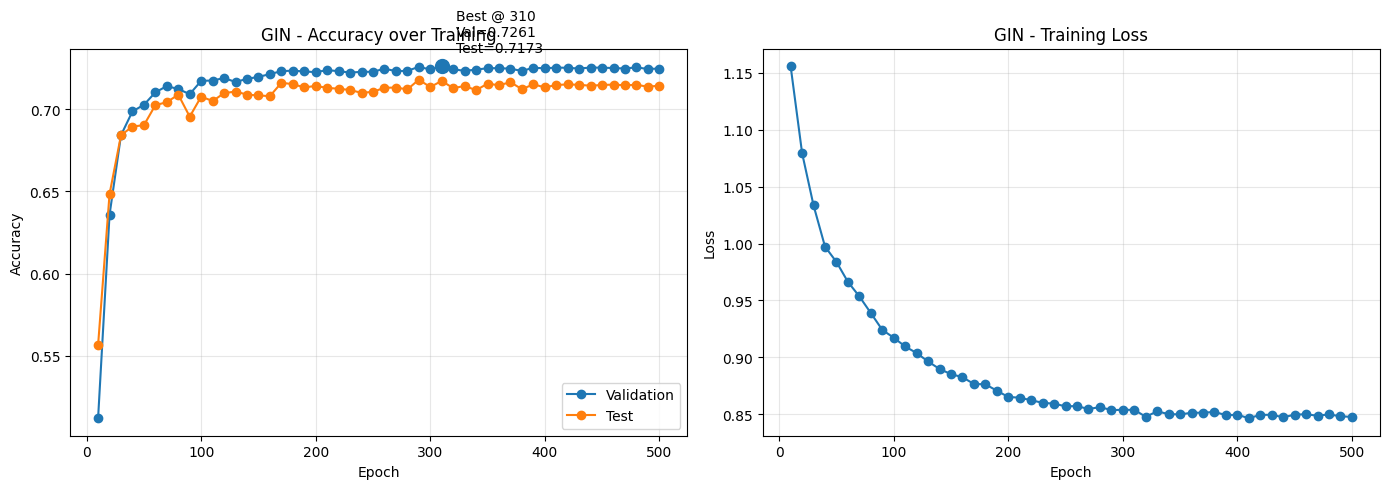

In [7]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 501, 10))

val_accs = [
    0.5120, 0.6358, 0.6842, 0.6987, 0.7027, 0.7103, 0.7141, 0.7123, 0.7092, 0.7173,
    0.7175, 0.7190, 0.7166, 0.7185, 0.7197, 0.7214, 0.7232, 0.7235, 0.7230, 0.7226,
    0.7238, 0.7232, 0.7223, 0.7228, 0.7228, 0.7247, 0.7232, 0.7234, 0.7258, 0.7242,
    0.7261, 0.7243, 0.7234, 0.7241, 0.7250, 0.7250, 0.7247, 0.7233, 0.7253, 0.7249,
    0.7254, 0.7252, 0.7248, 0.7254, 0.7253, 0.7251, 0.7248, 0.7255, 0.7245, 0.7248
]

test_accs = [
    0.5565, 0.6484, 0.6842, 0.6895, 0.6903, 0.7025, 0.7043, 0.7089, 0.6955, 0.7077,
    0.7050, 0.7098, 0.7108, 0.7089, 0.7084, 0.7080, 0.7161, 0.7153, 0.7133, 0.7142,
    0.7130, 0.7125, 0.7117, 0.7100, 0.7106, 0.7131, 0.7132, 0.7121, 0.7180, 0.7135,
    0.7173, 0.7128, 0.7142, 0.7116, 0.7156, 0.7146, 0.7165, 0.7122, 0.7152, 0.7133,
    0.7148, 0.7151, 0.7149, 0.7143, 0.7148, 0.7150, 0.7146, 0.7149, 0.7137, 0.7144
]

losses = [
    1.1558, 1.0795, 1.0335, 0.9973, 0.9838, 0.9663, 0.9535, 0.9389, 0.9241, 0.9172,
    0.9095, 0.9037, 0.8963, 0.8897, 0.8852, 0.8825, 0.8765, 0.8763, 0.8706, 0.8651,
    0.8645, 0.8622, 0.8600, 0.8592, 0.8569, 0.8571, 0.8545, 0.8562, 0.8536, 0.8538,
    0.8538, 0.8477, 0.8525, 0.8500, 0.8498, 0.8512, 0.8513, 0.8519, 0.8492, 0.8494,
    0.8465, 0.8493, 0.8495, 0.8472, 0.8496, 0.8499, 0.8486, 0.8498, 0.8481, 0.8476
]

best_idx = val_accs.index(max(val_accs))
best_epoch = epochs_logged[best_idx]
best_val = val_accs[best_idx]
best_test = test_accs[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, label='Validation', marker='o')
ax1.plot(epochs_logged, test_accs, label='Test', marker='o')

ax1.scatter(best_epoch, best_val, s=100)
ax1.annotate(
    f'Best @ {best_epoch}\nVal={best_val:.4f}\nTest={best_test:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10,10)
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GIN - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GIN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

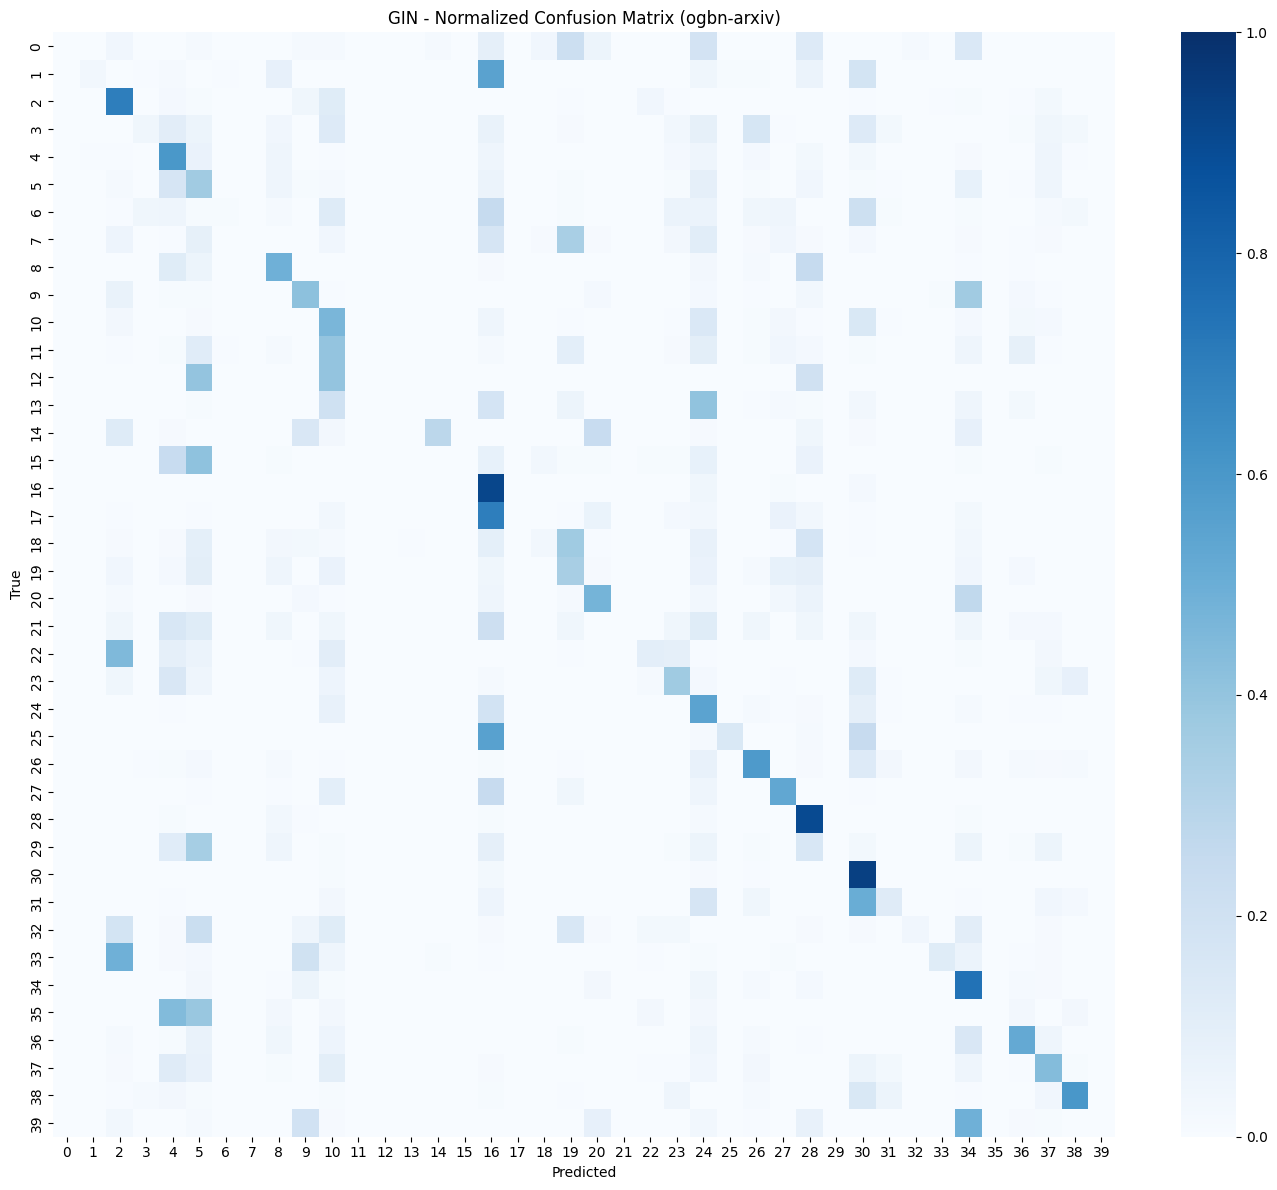

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import os
import torch

if os.path.exists('/kaggle/working/best_gin.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gin.pt', map_location=device))
elif os.path.exists('best_gin.pt'):
    model.load_state_dict(torch.load('best_gin.pt', map_location=device))

@torch.no_grad()
def get_test_predictions(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1)

    test_preds = pred[test_idx].detach().cpu()
    test_labels = data.y[test_idx].squeeze().detach().cpu()
    return test_labels, test_preds

test_labels, test_preds = get_test_predictions(model)

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=list(range(dataset.num_classes)))
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GIN - Normalized Confusion Matrix (ogbn-arxiv)')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

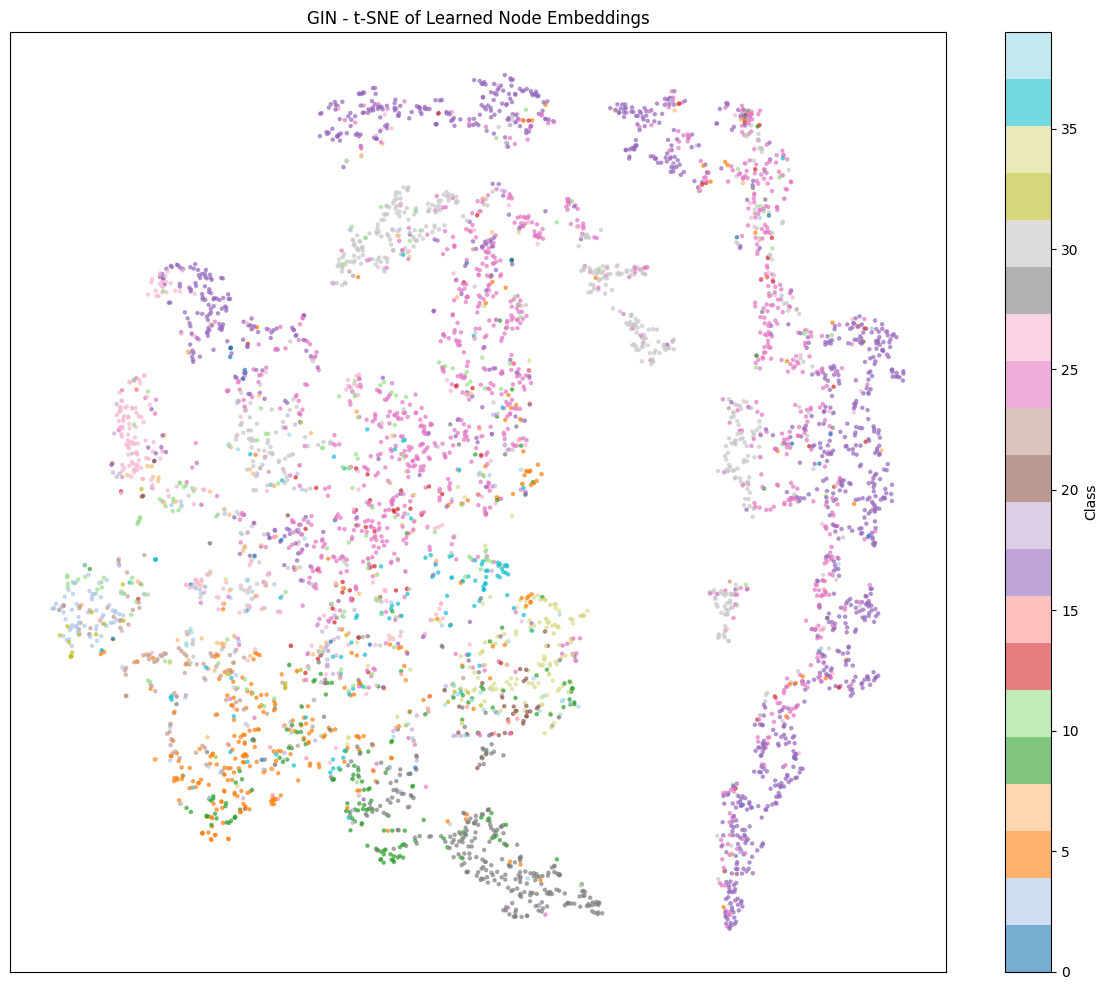

In [9]:
from sklearn.manifold import TSNE
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

if os.path.exists('/kaggle/working/best_gin.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gin.pt', map_location=device))
elif os.path.exists('best_gin.pt'):
    model.load_state_dict(torch.load('best_gin.pt', map_location=device))

@torch.no_grad()
def get_embeddings(model):
    model.eval()
    x = data.x
    for i, conv in enumerate(model.convs[:-1]):
        x = conv(x, data.edge_index)
        x = model.bns[i](x)
        x = F.relu(x)
    return x.detach().cpu()

all_embeds = get_embeddings(model)
test_embeds = all_embeds[test_idx.cpu()]
test_labels_for_tsne = data.y[test_idx].squeeze().detach().cpu()

n_samples = min(5000, len(test_embeds))
rng = np.random.default_rng(42)
indices = rng.choice(len(test_embeds), n_samples, replace=False)

embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels_for_tsne[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    embeds_2d[:, 0], embeds_2d[:, 1],
    c=labels_sub,
    cmap='tab20',
    s=5,
    alpha=0.6
)

ax.set_title('GIN - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])

plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()